# DIS08 – Student Housing (NRW)
## Phase: Explore (OSEMN)

**Research Questions in this notebook**
- **RQ-S1:** How do NRW university locations differ in dormitory supply (students per dorm place)?
- **RQ-S2:** Is dormitory supply related to the number of students?

This notebook uses the cleaned NRW dataset created in `02_scrub_student_housing.ipynb`.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt


C:\Users\User\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
path_nrw = "../../data/processed/student_housing_nrw_scrub.csv"
df_nrw = pd.read_csv(path_nrw)

df_nrw.shape, df_nrw.head()


((17, 6),
   hochschulort  wohnheime_2025_anzahl  wohnheimplaetze_2025  \
 0       Aachen                   35.0                5460.0   
 1    Bielefeld                   25.0                3193.0   
 2       Bochum                   37.0                5594.0   
 3         Bonn                   35.0                4053.0   
 4     Dortmund                   13.0                2765.0   
 
    studierende_ws_2024_2025  studierende_je_wohnheimplatz_2025  \
 0                   56493.0                               10.0   
 1                   31399.0                               10.0   
 2                   49371.0                                9.0   
 3                   34744.0                                9.0   
 4                   42769.0                               15.0   
 
    wohnheimplatzrelation  
 0              10.346703  
 1               9.833699  
 2               8.825706  
 3               8.572415  
 4              15.467993  )

In [3]:
df_nrw.info()
df_nrw.isna().sum()
df_nrw.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 6 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   hochschulort                       17 non-null     object 
 1   wohnheime_2025_anzahl              17 non-null     float64
 2   wohnheimplaetze_2025               17 non-null     float64
 3   studierende_ws_2024_2025           17 non-null     float64
 4   studierende_je_wohnheimplatz_2025  17 non-null     float64
 5   wohnheimplatzrelation              17 non-null     float64
dtypes: float64(5), object(1)
memory usage: 944.0+ bytes


,wohnheime_2025_anzahl,wohnheimplaetze_2025,studierende_ws_2024_2025,studierende_je_wohnheimplatz_2025,wohnheimplatzrelation
count,17.000000,17.000000,17.000000,17.000000,17.000000
mean,20.176471,2563.529412,29234.529412,18.235294,18.203615
std,23.192766,2131.753390,21463.076367,14.922841,14.942020
min,1.000000,31.000000,2172.000000,9.000000,8.572415
25%,6.000000,950.000000,13015.000000,10.000000,9.839935
50%,13.000000,1843.000000,26060.000000,14.000000,13.788044
75%,28.000000,4053.000000,42769.000000,17.000000,17.159408
max,96.000000,5997.000000,75655.000000,70.000000,70.064516


In [4]:
rq1_table = (
    df_nrw[["hochschulort", "studierende_je_wohnheimplatz_2025", "wohnheimplaetze_2025", "studierende_ws_2024_2025"]]
    .sort_values("studierende_je_wohnheimplatz_2025", ascending=True)
    .reset_index(drop=True)
)

rq1_table


,hochschulort,studierende_je_wohnheimplatz_2025,wohnheimplaetze_2025,studierende_ws_2024_2025
0,Bochum,9.0,5594.0,49371.0
1,Bonn,9.0,4053.0,34744.0
2,Münster,9.0,5997.0,54107.0
3,Aachen,10.0,5460.0,56493.0
4,Bielefeld,10.0,3193.0,31399.0
5,Paderborn,10.0,1843.0,18135.0
6,Düsseldorf,11.0,3597.0,40820.0
7,Duisburg,14.0,950.0,13015.0
8,Siegen,14.0,1043.0,14439.0
9,Köln,14.0,5487.0,75655.0


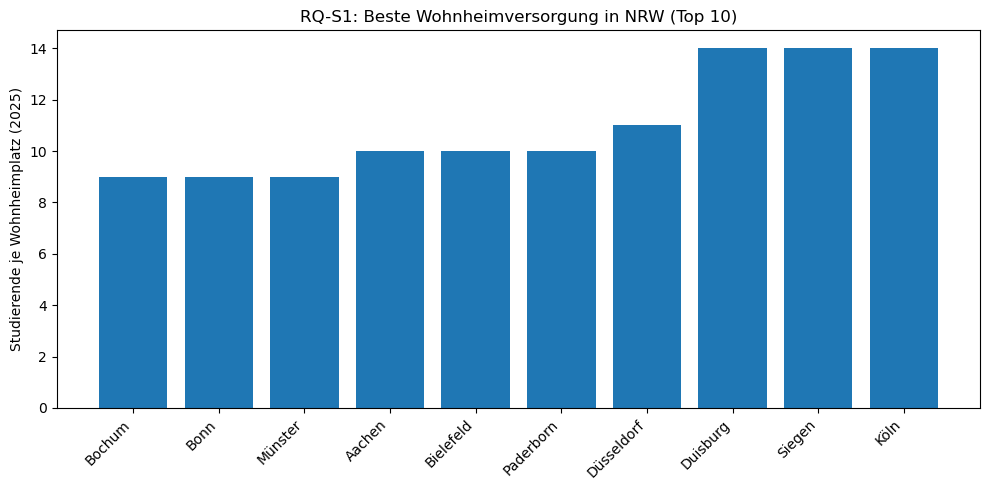

In [5]:
top10_best = rq1_table.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top10_best["hochschulort"], top10_best["studierende_je_wohnheimplatz_2025"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Studierende je Wohnheimplatz (2025)")
plt.title("RQ-S1: Beste Wohnheimversorgung in NRW (Top 10)")
plt.tight_layout()
plt.show()


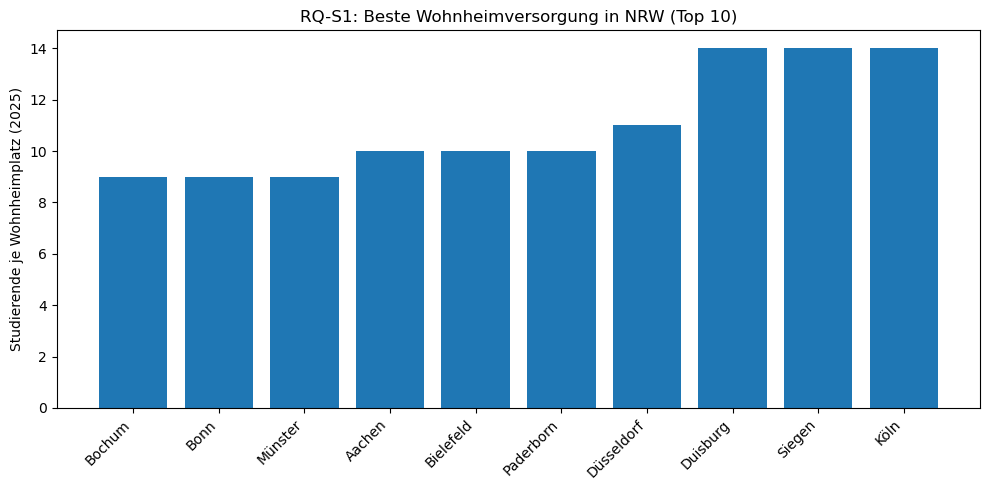

In [8]:
top10_best = rq1_table.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top10_best["hochschulort"], top10_best["studierende_je_wohnheimplatz_2025"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Studierende je Wohnheimplatz (2025)")
plt.title("RQ-S1: Beste Wohnheimversorgung in NRW (Top 10)")
plt.tight_layout()
plt.show()


### Interpretation RQ-S1

Die Abbildung zeigt deutliche Unterschiede in der Wohnheimversorgung zwischen
den Hochschulorten in NRW. Städte mit einer geringeren Anzahl an Studierenden
pro Wohnheimplatz weisen eine vergleichsweise bessere Versorgung auf.
Insbesondere kleinere oder spezialisierte Hochschulstandorte schneiden hier
besser ab als große Universitätsstädte.

Diese Ergebnisse berücksichtigen ausschließlich die Relation zwischen
Studierendenzahl und Wohnheimplätzen und treffen noch keine Aussage über
Mietpreise oder private Wohnungsangebote.


 die besten Orte für Studenten sind Bochum, Bonn, Münster. Vom Vorteil sind diese Städte, da dort auf einen Wohnheimplatz weniger studenten kommen.
Mietpreise sind nicht berücksichtigt.


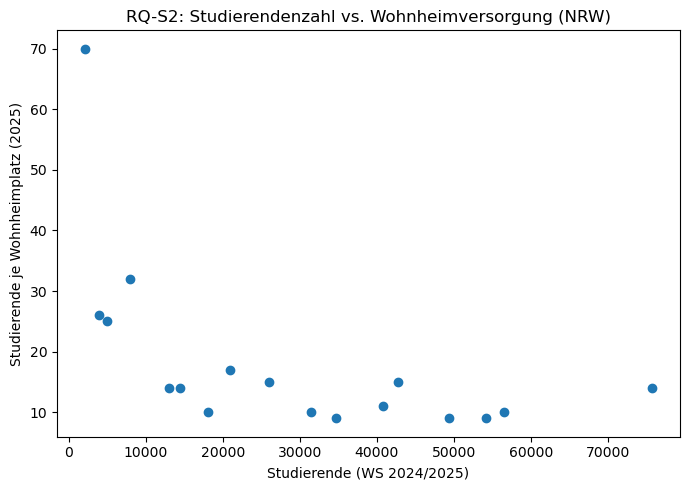

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(df_nrw["studierende_ws_2024_2025"], df_nrw["studierende_je_wohnheimplatz_2025"])
plt.xlabel("Studierende (WS 2024/2025)")
plt.ylabel("Studierende je Wohnheimplatz (2025)")
plt.title("RQ-S2: Studierendenzahl vs. Wohnheimversorgung (NRW)")
plt.tight_layout()
plt.show()


In [7]:
from scipy.stats import spearmanr

rho, p = spearmanr(df_nrw["studierende_ws_2024_2025"], df_nrw["studierende_je_wohnheimplatz_2025"])
rho, p


(-0.7066317984089711, 0.0015177924134718852)

Richtung: rho > 0 oder < 0?

grob: schwach/mittel/stark (nur qualitativ)

p < 0.05 ja/nein

keine Kausalität behaupten

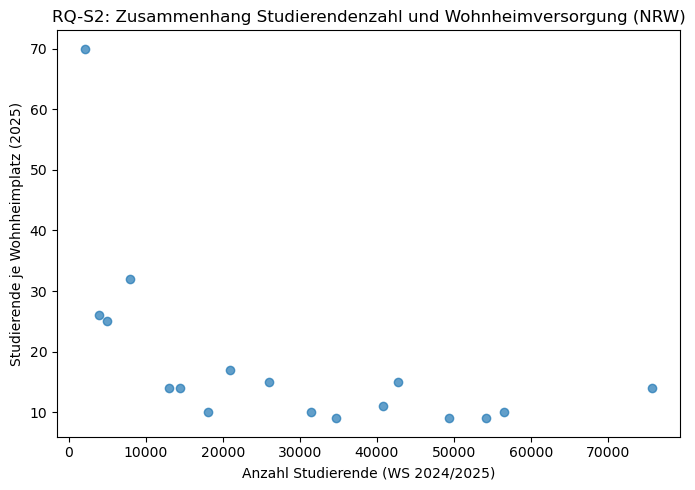

In [9]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df_nrw["studierende_ws_2024_2025"],
    df_nrw["studierende_je_wohnheimplatz_2025"],
    alpha=0.7
)

plt.xlabel("Anzahl Studierende (WS 2024/2025)")
plt.ylabel("Studierende je Wohnheimplatz (2025)")
plt.title("RQ-S2: Zusammenhang Studierendenzahl und Wohnheimversorgung (NRW)")
plt.tight_layout()
plt.show()
